# User Retention & Churn Analysis
## Notebook 2: Data Preprocessing & Feature Engineering

**Author:** Vijayalakshmi Veeraiyan  
**Previous:** Notebook 1 — Data Exploration  
**Next:** Notebook 3 — Modeling & Business Impact

---

## What This Notebook Does

In Notebook 1 we explored the data and
discovered five key patterns:
- Class imbalance (26.5% churn rate)
- Contract type drives churn most strongly
- Referrals signal loyalty
- Early tenure is the highest risk period
- Higher monthly charges correlate with churn

Now we prepare the data for machine learning
by doing three things:

**1. Data Cleaning**
Fix quality issues like negative values,
wrong data types and meaningful
missing values

**2. Feature Engineering**
Create new variables that capture
patterns the raw columns miss,
especially the early tenure risk
we discovered in Notebook 1

**3. Preprocessing Pipeline**
Scale numerical features and encode
categorical features so our machine
learning algorithm can process them

---

## Why Preprocessing Matters

Raw data is almost never ready for
machine learning directly.

Machine learning algorithms work with
numbers not text. They are sensitive
to scale, a column ranging 0-1000
will dominate a column ranging 0-1
unless we normalise them. They cannot
handle missing values without guidance.

The quality of preprocessing directly
determines the quality of the model.

**Garbage in — garbage out.**

A well-preprocessed dataset gives the
algorithm the best possible chance of
finding real patterns rather than
learning from noise.

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load the Dataset

In [ ]:
file_path = '/content/telecom_customer_churn.csv'
df = pd.read_csv(file_path)
print(f'Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns')

Dataset loaded: 7043 rows x 38 columns


## 3. Data Cleaning

Based on the exploration in Notebook 1, we identified:
- Negative values in monetary columns (e.g. -4 in Monthly Charge)
- Missing values in Churn Category and Churn Reason for non-churned customers
- Zip Code stored as integer (should be string to preserve leading zeros)

In [ ]:
def clean_data(df):
    """
    Clean the raw dataset:
    - Fix negative monetary values
    - Handle missing values in churn-related columns
    - Fix data types
    """
    df_clean = df.copy()

    # Fix negative values in monetary columns
    monetary_columns = [
        'Monthly Charge', 'Total Charges', 'Total Refunds',
        'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue'
    ]

    for col in monetary_columns:
        negative_count = (df_clean[col] < 0).sum()
        if negative_count > 0:
            print(f'Fixed {negative_count} negative values in {col}')
            df_clean[col] = np.where(
                df_clean[col] < 0,
                df_clean[col].median(),
                df_clean[col]
            )

    # Convert Zip Code to string
    df_clean['Zip Code'] = df_clean['Zip Code'].astype(str)

    # Fill missing Churn Category and Reason for non-churned customers
    df_clean['Churn Category'] = df_clean['Churn Category'].fillna('No Churn')
    df_clean['Churn Reason'] = df_clean['Churn Reason'].fillna('No Churn')

    print(f'\nCleaning complete. Dataset shape: {df_clean.shape}')
    return df_clean

df_clean = clean_data(df)
print('\nMissing values after cleaning:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Fixed 120 negative values in Monthly Charge

Cleaning complete. Dataset shape: (7043, 38)

Missing values after cleaning:
Offer                                3877
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                     1526
Streaming Music                      1526
Unlimited Data                       1526
dtype: int64


## Why We Clean the Data This Way

### Problem 1 — Negative Monthly Charge

We found one customer with a Monthly
Charge of -$4. A negative charge is
physically impossible as this is clearly
a data entry error.

**Why we replace with median (not mean):**

The median is more robust to outliers
than the mean. If there were several
extreme values in the column, the mean
would be pulled toward them and giving
a distorted replacement value. The
median always represents the middle
of the distribution regardless of
extreme values.

**Why not just delete the row?**

Deleting rows because of one bad value
in one column wastes all the other
valid information in that row. The
customer's contract type, tenure,
referrals, and churn status are all
still valid and useful. We fix the
one bad value and keep everything else.

---

### Problem 2 — Missing Churn Category and Churn Reason

5,174 customers (73.5%) have no Churn
Category or Churn Reason recorded.

This is not missing data in the
traditional sense as these customers
simply did not churn. There is no
churn reason to record for someone
who stayed.

Filling with **"No Churn"** is the
correct approach as it creates a
meaningful category rather than
leaving a blank that the imputer
might fill incorrectly.

---

### Problem 3 — Zip Code as Integer

Zip codes stored as integers lose
leading zeros. For example, zip code
"01234" becomes "1234". This corrupts
location data.

Converting to string preserves the
original format and prevents the model
from treating zip codes as meaningful
numerical values (a higher zip code
number does not mean anything).

---

### The Professional Mindset

Every data cleaning decision should
have a reason. Randomly dropping rows
or filling values without thought
introduces bias and loses information.

The questions to always ask are:
→ Why is this value wrong or missing?
→ What is the least destructive fix?
→ Does this fix introduce any new bias?

## 4. Feature Engineering

Creating new features based on domain knowledge and observations from the data exploration:
- **Tenure in years** — more interpretable than months
- **Age groups** — to capture generational patterns
- **Premium services count** — total number of add-ons per customer
- **High data user flag** — binary indicator for heavy data usage
- **Monthly spend ratio** — monthly charge relative to tenure (key churn signal)

In [ ]:
def feature_engineering(df):
    """
    Engineer new features from existing columns:
    - Binary churn target variable
    - Tenure in years
    - Age group bins
    - Premium services count
    - High data user flag
    - Monthly spend ratio
    """
    df_feat = df.copy()

    # Target variable — binary churn indicator
    df_feat['Churned_Binary'] = np.where(
        df_feat['Customer Status'] == 'Churned', 1, 0
    )

    # Tenure in years
    df_feat['Tenure_Years'] = df_feat['Tenure in Months'] / 12

    # Age groups
    df_feat['Age_Group'] = pd.cut(
        df_feat['Age'],
        bins=[0, 30, 45, 60, 100],
        labels=['Under 30', '30-45', '46-60', 'Over 60']
    )

    # Count of premium services per customer
    premium_services = [
        'Online Security', 'Online Backup', 'Device Protection Plan',
        'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music'
    ]
    df_feat['Premium_Services_Count'] = 0
    for service in premium_services:
        df_feat['Premium_Services_Count'] += np.where(
            df_feat[service] == 'Yes', 1, 0
        )

    # High data user flag (above 50 GB/month)
    df_feat['High_Data_User'] = np.where(
        df_feat['Avg Monthly GB Download'] > 50, 1, 0
    )

    # Monthly spend ratio — high ratio = paying a lot relative to tenure
    # This captures customers who are expensive but haven't been with us long
    df_feat['Monthly_Spend_Ratio'] = (
        df_feat['Monthly Charge'] /
        df_feat['Tenure in Months'].replace(0, 1)  # avoid division by zero
    )

    print('New features created:')
    new_features = ['Churned_Binary', 'Tenure_Years', 'Age_Group',
                    'Premium_Services_Count', 'High_Data_User', 'Monthly_Spend_Ratio']
    for f in new_features:
        print(f'  - {f}')

    return df_feat

df_featured = feature_engineering(df_clean)
print(f'\nDataset shape after feature engineering: {df_featured.shape}')

New features created:
  - Churned_Binary
  - Tenure_Years
  - Age_Group
  - Premium_Services_Count
  - High_Data_User
  - Monthly_Spend_Ratio

Dataset shape after feature engineering: (7043, 44)


## Why We Engineer New Features

### The Core Idea

Raw data captures **what happened** —
feature engineering helps the model
understand **why it happened.**

The original 38 columns tell us facts
about each customer. Our engineered
features combine those facts into
meaningful signals that better
capture churn risk.


---

### Feature 1 — Churned_Binary

**What:** Converts Customer Status
into a simple 0/1 number

**Why:** Machine learning algorithms
require numerical targets.
"Churned" and "Stayed" are text —
1 and 0 are numbers the algorithm
can learn from.

---

### Feature 2 — Tenure_Years

**What:** Tenure in Months divided by 12

**Why:** Years is more interpretable
than months for business stakeholders.
A customer with 2.5 years tenure is
easier to reason about than one with
30 months tenure. Both contain the
same information — one is just more
human-friendly.

---

### Feature 3 — Age_Group

**What:** Age divided into four bands —
Under 30, 30-45, 46-60, Over 60

**Why:** The relationship between age
and churn may not be linear. A
25-year-old and a 29-year-old may
behave similarly — but very differently
from a 45-year-old. Binning captures
these generational patterns better
than raw age numbers.

---

### Feature 4 — Premium_Services_Count

**What:** Total number of premium
services each customer subscribes to
(Online Security, Backup, Device
Protection, Tech Support, Streaming
TV, Movies, Music)

**Why:** Each additional service
increases switching cost. A customer
using 6 services would need to find
replacements for all 6 if they left.
This creates natural loyalty — the
more services used, the harder it
is to leave.

---

### Feature 5 — High_Data_User

**What:** Binary flag for customers
downloading more than 50GB per month

**Why:** Heavy data users have
stronger dependency on internet
service quality. They may be more
sensitive to speed issues — but
also more locked in because finding
equivalent service elsewhere is harder.

---

### Feature 6 — Monthly_Spend_Ratio

**What:** Monthly Charge divided
by Tenure in Months

**Why:** This is our most insightful
engineered feature — confirmed as
the **third strongest predictor**
in our final model (importance: 0.073)



**Month 1, $80/month:**
High spend, no loyalty yet,
still evaluating value → HIGH RISK

**Month 36, $80/month:**
Same spend, proven loyalty,
embedded in service → LOW RISK

The ratio captures this relationship
in a single powerful number —
something neither Monthly Charge
nor Tenure alone could express.

## 5. Visualise Engineered Features

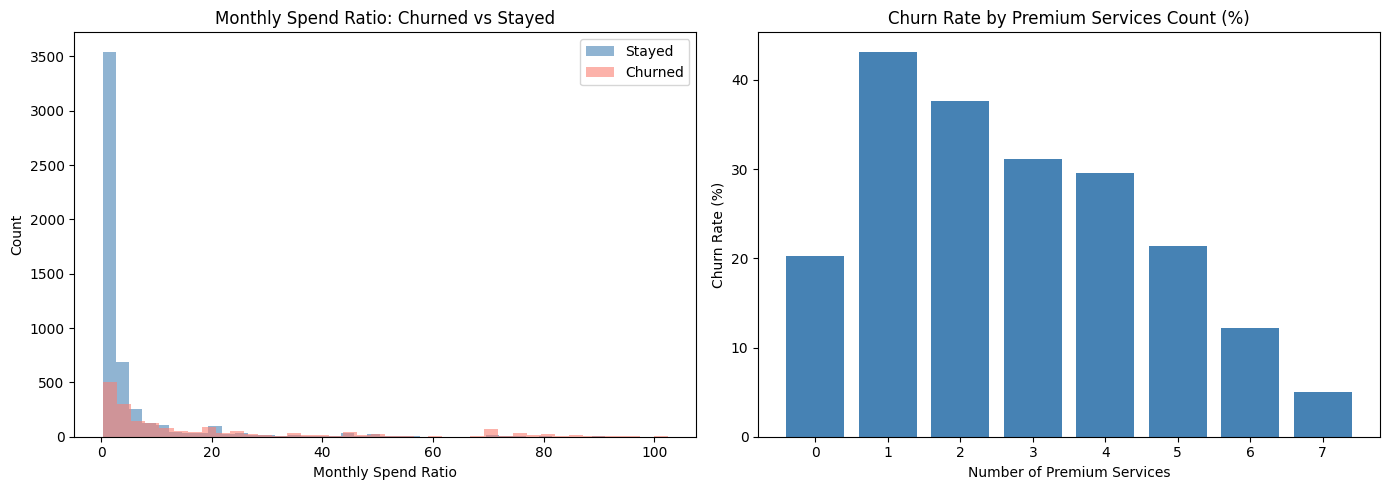

In [ ]:
# Monthly Spend Ratio — churned vs stayed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly Spend Ratio distribution
churned_ratio = df_featured[df_featured['Churned_Binary'] == 1]['Monthly_Spend_Ratio']
stayed_ratio = df_featured[df_featured['Churned_Binary'] == 0]['Monthly_Spend_Ratio']

axes[0].hist(stayed_ratio, bins=40, alpha=0.6, label='Stayed', color='steelblue')
axes[0].hist(churned_ratio, bins=40, alpha=0.6, label='Churned', color='salmon')
axes[0].set_title('Monthly Spend Ratio: Churned vs Stayed', fontsize=12)
axes[0].set_xlabel('Monthly Spend Ratio')
axes[0].set_ylabel('Count')
axes[0].legend()

# Premium Services Count by churn status
premium_churn = df_featured.groupby('Premium_Services_Count')['Churned_Binary'].mean() * 100
axes[1].bar(premium_churn.index, premium_churn.values, color='steelblue')
axes[1].set_title('Churn Rate by Premium Services Count (%)', fontsize=12)
axes[1].set_xlabel('Number of Premium Services')
axes[1].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Prepare Data for Modeling

Steps:
- Define target variable (Churned_Binary)
- Remove columns not needed for modeling
- Separate categorical and numerical features
- Build preprocessing pipelines
- Split into train and test sets

In [ ]:
def prepare_modeling_data(df):
    """
    Prepare data for modeling:
    - Define X (features) and y (target)
    - Build preprocessing pipelines for numerical and categorical features
    - Split into train and test sets (80/20)
    """
    df_prep = df.copy()

    # Target variable
    y = df_prep['Churned_Binary']

    # Drop columns not needed for modeling
    columns_to_drop = [
        'Customer ID', 'Churned_Binary', 'Customer Status',
        'Churn Category', 'Churn Reason',
        'Zip Code', 'Latitude', 'Longitude', 'City'
    ]
    X = df_prep.drop(columns=columns_to_drop)

    # Identify categorical and numerical columns
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    print(f'Features: {X.shape[1]} total')
    print(f'  Categorical: {len(categorical_cols)}')
    print(f'  Numerical: {len(numerical_cols)}')

    # Preprocessing pipeline for numerical features
    numerical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),  # fill missing with median
        ('scaler', StandardScaler())                    # scale to mean=0, std=1
    ])

    # Preprocessing pipeline for categorical features
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),  # fill missing with mode
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    # Combine both pipelines
    preprocessor = ColumnTransformer(transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

    # Train/test split — 80% train, 20% test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Apply preprocessing
    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    # Get feature names after one-hot encoding
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols).tolist()
    all_feature_names = numerical_cols + cat_feature_names

    print(f'\nTrain set: {X_train_processed.shape[0]} samples')
    print(f'Test set: {X_test_processed.shape[0]} samples')
    print(f'Total features after encoding: {X_train_processed.shape[1]}')

    return (
        X_train_processed, X_test_processed,
        y_train, y_test,
        preprocessor, all_feature_names
    )

X_train, X_test, y_train, y_test, preprocessor, feature_names = prepare_modeling_data(df_featured)

print(f'\nClass distribution in training set:')
print(pd.Series(y_train).value_counts(normalize=True).round(3))

Features: 35 total
  Categorical: 19
  Numerical: 16

Train set: 5634 samples
Test set: 1409 samples
Total features after encoding: 62

Class distribution in training set:
Churned_Binary
0    0.734
1    0.266
Name: proportion, dtype: float64


## Why We Build Preprocessing Pipelines

### What is a Pipeline?

A pipeline chains multiple preprocessing
steps together in a defined order
ensuring every transformation happens
consistently and in the right sequence.

Think of it like a factory assembly line:
- Raw material enters at one end
- Each station performs one transformation
- Finished product comes out the other end

Without a pipeline, it's easy to apply
steps in the wrong order or forget to
apply them consistently to both training
and test data.

---

### Numerical Pipeline — Two Steps

**Step 1: SimpleImputer (strategy=median)**

Fills any remaining missing numerical
values with the column median.

Why median and not mean?
- Mean is sensitive to outliers
- One extreme value shifts the mean
  significantly
- Median always represents the true
  middle of the distribution
- More robust for real world messy data

**Step 2: StandardScaler**

Scales every numerical column to have:
- Mean = 0
- Standard deviation = 1

Why is this necessary?

Consider two columns:
- Monthly Charge: ranges $20 to $120
- Tenure in Months: ranges 1 to 72

Without scaling, Tenure dominates
simply because its numbers are larger
and not because it's more important.

StandardScaler puts every numerical
feature on equal footing so the
algorithm evaluates them fairly.

---

### Categorical Pipeline — Two Steps

**Step 1: SimpleImputer (strategy=most_frequent)**

Fills missing categorical values with
the most common value in that column.

For example, If most customers use
"Bank Withdrawal" as payment method,
any missing payment method values
are filled with "Bank Withdrawal."

**Step 2: OneHotEncoder**

Converts text categories into numbers.

For example — Contract Type becomes:
- Month-to-Month → [1, 0, 0]
- One Year → [0, 1, 0]
- Two Year → [0, 0, 1]

Why not just use 1, 2, 3?

Using numbers 1, 2, 3 implies that
Two Year (3) is mathematically "more"
than Month-to-Month (1) which is
meaningless. One Hot Encoding treats
each category as completely independent
with no implied ordering.

---

### ColumnTransformer — Combining Both

The ColumnTransformer applies the
numerical pipeline to numerical columns
and the categorical pipeline to
categorical columns simultaneously in a single step.

This ensures every column receives
the correct preprocessing treatment
automatically.


## 7. Save Processed Data

Save the processed arrays for use in Notebook 3.

In [ ]:
import joblib
import numpy as np

# Save processed data
np.save('/content/X_train.npy', X_train)
np.save('/content/X_test.npy', X_test)
np.save('/content/y_train.npy', y_train)
np.save('/content/y_test.npy', y_test)

# Save preprocessor and feature names
joblib.dump(preprocessor, '/content/preprocessor.pkl')
joblib.dump(feature_names, '/content/feature_names.pkl')

print('All processed data saved successfully!')
print('Files saved:')
print('  X_train.npy, X_test.npy, y_train.npy, y_test.npy')
print('  preprocessor.pkl, feature_names.pkl')
print('\nOpen Notebook 3 (3_modeling.ipynb) to train and evaluate the model.')

All processed data saved successfully!
Files saved:
  X_train.npy, X_test.npy, y_train.npy, y_test.npy
  preprocessor.pkl, feature_names.pkl

Open Notebook 3 (3_modeling.ipynb) to train and evaluate the model.


## Why We Save Processed Data

### The Problem With Running Everything Together

Our full pipeline has three notebooks:
- Notebook 1 — Exploration (5 minutes)
- Notebook 2 — Preprocessing (3 minutes)
- Notebook 3 — Modeling (15-20 minutes)

If we had one giant notebook, every
time we wanted to tweak the model we
would need to re-run exploration and
preprocessing from scratch. That wastes
time and makes experimentation slow.

### The Solution — Save Intermediate Outputs

By saving processed data at the end
of Notebook 2, Notebook 3 can load
it directly — skipping all the
preprocessing steps entirely.

This is a professional data science
practice called **pipeline separation** by
keeping distinct stages of the workflow
independent from each other.

### What We Save and Why

**X_train.npy and X_test.npy**
The preprocessed feature matrices —
scaled numerical values and one-hot
encoded categorical values are ready
for the model to consume directly.

**y_train.npy and y_test.npy**
The target variable arrays —
1 for churned, 0 for stayed are
for training and evaluation.

**preprocessor.pkl**
The fitted preprocessing pipeline is
saved so we can apply identical
transformations to new customer
data in production. This is critical
for deployment as the Streamlit app
will use this exact preprocessor
to transform new inputs before
passing them to the model.

**feature_names.pkl**
The complete list of feature names
after one-hot encoding is used in
Notebook 3 for feature importance
visualisation.



### Real World Application

In production deployment, the
preprocessor.pkl file is used to
transform new customer data before
prediction — ensuring new inputs
are processed identically to how
training data was processed.

This is the bridge between our
notebook experiment and the
Streamlit web application we
are building next.

## 8. Preprocessing Summary

| Step | Action | Reason |
|---|---|---|
| Negative values | Replaced with median | Data quality issue |
| Missing churn columns | Filled with 'No Churn' | Customers who stayed have no churn reason |
| Zip Code | Converted to string | Preserve leading zeros |
| Numerical missing | Imputed with median | Robust to outliers |
| Categorical missing | Imputed with mode | Most common value |
| Numerical scaling | StandardScaler | Required for gradient-based models |
| Categorical encoding | OneHotEncoder | Convert text to numbers |
| Train/test split | 80/20 | Standard evaluation practice |

---
**Next:** Open `3_modeling.ipynb` to train and evaluate machine learning models.